# Llm deliberation evidence freeze

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 03
## LLM-Deliberation evidence freeze

This notebook freezes the completed LLM-Deliberation evidence after the Notebook 02b repair.

It performs **no new model generation** and does not load a GPU model. Its job is to make the current primary result reproducible from frozen data:

- rederive the locked leave-one-trajectory-out H1 estimate from saved activations;
- rederive the matched-auditor comparison and clustered uncertainty;
- retain the nested-reader analysis as secondary robustness only;
- rederive the repaired private/public report result;
- retain the exact-repeat and report-order controls;
- create paper-ready diagnostic figures and compact tables;
- hash every frozen input and every final artifact.

Every artifact lives under:

`/workspace/latent-reservations/notebook_outputs/03_llm_deliberation_evidence_freeze/<RUN_ID>/`


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook03-evidence-freeze-run-all-v1"
print("=" * 78)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("LLM-Deliberation evidence freeze")
print("=" * 78)


NOTEBOOK BUILD: latent-reservations-notebook03-evidence-freeze-run-all-v1
LLM-Deliberation evidence freeze


## 1. Dependencies


In [2]:
import importlib.util, subprocess, sys
required = {
    "numpy": "numpy<2",
    "pandas": "pandas>=2,<3",
    "scipy": "scipy>=1.12,<2",
    "sklearn": "scikit-learn>=1.4,<2",
    "matplotlib": "matplotlib>=3.8,<4",
    "safetensors": "safetensors>=0.4",
    "tqdm": "tqdm>=4.66",
}
missing = [pkg for mod,pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
print("Notebook 03 dependencies ready.")


Notebook 03 dependencies ready.


## 2. Paths and isolated run directory


In [3]:
from __future__ import annotations
import hashlib, json, os, shutil
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
NOTEBOOK_SLUG = "03_llm_deliberation_evidence_freeze"
RUN_ID = os.environ.get("LR_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = BASE / RUN_ID
INPUT_DIR = RUN_OUTPUT_DIR / "inputs"
RESULTS_DIR = RUN_OUTPUT_DIR / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
for p in [INPUT_DIR / "states", TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]: p.mkdir(parents=True, exist_ok=True)
BASE.mkdir(parents=True, exist_ok=True)
(BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))
print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/03_llm_deliberation_evidence_freeze/20260814T014816Z


## 3. Snapshot Notebook 02b and its frozen parents

Notebook 02b is the authoritative repaired branch. Notebook 03 copies every input needed for the final analysis before recomputing anything.


In [4]:
NB02B_BASE = PROJECT_ROOT / "notebook_outputs" / "02b_llm_deliberation_report_replay_repair"
latest = NB02B_BASE / "latest_run.json"
if not latest.exists(): raise FileNotFoundError(latest)
NB02B_RUN = Path(json.loads(latest.read_text())["run_output_dir"])

required = [
    NB02B_RUN / "inputs" / "pilot_all_layers.safetensors",
    NB02B_RUN / "inputs" / "pilot_all_layers_index.json",
    NB02B_RUN / "inputs" / "actions.jsonl",
    NB02B_RUN / "inputs" / "auditor.jsonl",
    NB02B_RUN / "inputs" / "pilot_summary.json",
    NB02B_RUN / "inputs" / "notebook02_robustness_summary.json",
    NB02B_RUN / "results" / "tables" / "repair_summary.json",
    NB02B_RUN / "results" / "tables" / "nested_loto_state_predictions.csv",
    NB02B_RUN / "results" / "tables" / "nested_loto_by_trajectory.csv",
    NB02B_RUN / "results" / "tables" / "repaired_report_state_table.csv",
    NB02B_RUN / "results" / "tables" / "repaired_report_summary.json",
    NB02B_RUN / "results" / "tables" / "report_order_control.csv",
    NB02B_RUN / "results" / "tables" / "reparsed_exact_repeat_summary.json",
]
for p in required:
    if not p.exists(): raise FileNotFoundError(p)

for p in required:
    shutil.copy2(p, INPUT_DIR / p.name)
for p in sorted((NB02B_RUN / "inputs" / "states").glob("*.json")):
    shutil.copy2(p, INPUT_DIR / "states" / p.name)

print(json.dumps({
    "notebook02b_run": str(NB02B_RUN),
    "copied_states": len(list((INPUT_DIR / "states").glob("*.json"))),
    "copied_core_files": len(required),
}, indent=2))


{
  "notebook02b_run": "/workspace/latent-reservations/notebook_outputs/02b_llm_deliberation_report_replay_repair/20260814T013828Z",
  "copied_states": 30,
  "copied_core_files": 13
}


## 4. Hash frozen inputs


In [5]:
def sha256_file(path: Path, chunk=1024*1024):
    h=hashlib.sha256()
    with path.open('rb') as f:
        while True:
            b=f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

input_files = sorted([p for p in INPUT_DIR.rglob('*') if p.is_file()])
input_hashes = {str(p.relative_to(INPUT_DIR)): sha256_file(p) for p in tqdm(input_files, desc="Hash frozen inputs", unit="file")}
(MANIFEST_DIR / "frozen_input_hashes.json").write_text(json.dumps(input_hashes, indent=2))
print(f"Hashed {len(input_hashes)} frozen inputs")


Hash frozen inputs:   0%|          | 0/43 [00:00<?, ?file/s]

Hashed 43 frozen inputs


## 5. Load frozen observations


In [6]:
from safetensors.torch import load_file

states=[json.loads(p.read_text()) for p in sorted((INPUT_DIR/'states').glob('*.json'))]
state_by_id={s['state_id']:s for s in states}
actions=[json.loads(x) for x in (INPUT_DIR/'actions.jsonl').read_text().splitlines() if x.strip()]
action_by_id={r['state_id']:r for r in actions}
auditors=[json.loads(x) for x in (INPUT_DIR/'auditor.jsonl').read_text().splitlines() if x.strip()]
auditor_by_id={r['state_id']:r for r in auditors}
idx=json.loads((INPUT_DIR/'pilot_all_layers_index.json').read_text())['state_ids']
A=load_file(str(INPUT_DIR/'pilot_all_layers.safetensors'))['activations'].float().cpu().numpy()
pilot=json.loads((INPUT_DIR/'pilot_summary.json').read_text())
nb02=json.loads((INPUT_DIR/'notebook02_robustness_summary.json').read_text())
repair=json.loads((INPUT_DIR/'repair_summary.json').read_text())
reports=pd.read_csv(INPUT_DIR/'repaired_report_state_table.csv')
order_control=pd.read_csv(INPUT_DIR/'report_order_control.csv')
repeat_summary=json.loads((INPUT_DIR/'reparsed_exact_repeat_summary.json').read_text())

assert len(idx)==30 and A.shape[0]==30
assert set(idx)==set(state_by_id)==set(action_by_id)==set(auditor_by_id)
LOCKED_LAYER=int(pilot['selected_activation_layer'])
LOCKED_ALPHA=float(pilot['selected_activation_alpha'])
trajectory=np.array([state_by_id[s]['trajectory_id'] for s in idx])
y=np.array([float(action_by_id[s]['score']) for s in idx])
aud=np.array([float(auditor_by_id[s]['auditor_score']) for s in idx])
print({"states":len(idx),"trajectories":sorted(set(trajectory)),"locked_layer":LOCKED_LAYER,"locked_alpha":LOCKED_ALPHA,"activation_shape":list(A.shape)})


{'states': 30, 'trajectories': ['trajectory_000', 'trajectory_001', 'trajectory_002', 'trajectory_003', 'trajectory_004'], 'locked_layer': 12, 'locked_alpha': 0.1, 'activation_shape': [30, 28, 3584]}


## 6. Recompute the locked H1 estimate exactly

The original locked reader configuration remains fixed. Entire source trajectories are held out one at a time.


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

locked_pred=np.full(len(idx),np.nan)
fold_rows=[]
for tid in tqdm(sorted(set(trajectory)), desc="Locked LOTO folds", unit="trajectory"):
    te=trajectory==tid
    tr=~te
    mdl=make_pipeline(StandardScaler(), Ridge(alpha=LOCKED_ALPHA))
    mdl.fit(A[tr,LOCKED_LAYER,:], y[tr])
    locked_pred[te]=mdl.predict(A[te,LOCKED_LAYER,:])
    am=float(mean_absolute_error(y[te],locked_pred[te]))
    tm=float(mean_absolute_error(y[te],aud[te]))
    fold_rows.append({"trajectory_id":tid,"n":int(te.sum()),"activation_mae":am,"auditor_mae":tm,"delta_auditor_minus_activation":tm-am})
    tqdm.write(f"{tid}: activation={am:.3f} auditor={tm:.3f} delta={tm-am:.3f}")

locked_mae=float(mean_absolute_error(y,locked_pred))
auditor_mae=float(mean_absolute_error(y,aud))
delta=float(auditor_mae-locked_mae)
if abs(locked_mae-float(nb02['locked_activation_loto_mae'])) > 1e-3:
    raise RuntimeError(f"Locked recomputation drift: {locked_mae} vs {nb02['locked_activation_loto_mae']}")
if abs(auditor_mae-float(nb02['auditor_loto_mae'])) > 1e-9:
    raise RuntimeError("Auditor recomputation drift")

fold_df=pd.DataFrame(fold_rows)
fold_df.to_csv(TABLE_DIR/'h1_locked_loto_by_trajectory.csv',index=False)
state_pred=pd.DataFrame({
    'state_id':idx,
    'trajectory_id':trajectory,
    'revealed_score':y,
    'activation_locked_pred':locked_pred,
    'auditor_pred':aud,
})
state_pred['activation_abs_error']=abs(state_pred.revealed_score-state_pred.activation_locked_pred)
state_pred['auditor_abs_error']=abs(state_pred.revealed_score-state_pred.auditor_pred)
state_pred.to_csv(TABLE_DIR/'h1_locked_state_predictions.csv',index=False)
print({"locked_activation_mae":locked_mae,"auditor_mae":auditor_mae,"delta_latent":delta})


Locked LOTO folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

trajectory_000: activation=25.160 auditor=12.833 delta=-12.327
trajectory_001: activation=13.753 auditor=8.167 delta=-5.586
trajectory_002: activation=15.100 auditor=7.667 delta=-7.433
trajectory_003: activation=44.346 auditor=8.333 delta=-36.013
trajectory_004: activation=26.116 auditor=15.000 delta=-11.116
{'locked_activation_mae': 24.89508310953776, 'auditor_mae': 10.4, 'delta_latent': -14.495083109537761}


## 7. Trajectory-cluster bootstrap uncertainty


In [8]:
BOOTSTRAP_REPS=int(os.environ.get('LR_H1_BOOTSTRAP_REPS','10000'))
rng=np.random.default_rng(7319)
trajectories=sorted(set(trajectory))
cluster_idx={tid:np.flatnonzero(trajectory==tid) for tid in trajectories}
per_state_delta=abs(y-aud)-abs(y-locked_pred)
boots=np.empty(BOOTSTRAP_REPS)
for b in tqdm(range(BOOTSTRAP_REPS),desc="H1 cluster bootstrap",unit="rep"):
    sampled=rng.choice(trajectories,size=len(trajectories),replace=True)
    sel=np.concatenate([cluster_idx[t] for t in sampled])
    boots[b]=float(per_state_delta[sel].mean())
ci=[float(v) for v in np.quantile(boots,[0.025,0.975])]
boot_summary={
    'reps':BOOTSTRAP_REPS,
    'delta_latent':delta,
    'ci95':ci,
    'fraction_positive':float(np.mean(boots>0)),
    'cluster_unit':'source trajectory',
}
(TABLE_DIR/'h1_cluster_bootstrap.json').write_text(json.dumps(boot_summary,indent=2))
print(json.dumps(boot_summary,indent=2))


H1 cluster bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "reps": 10000,
  "delta_latent": -14.495083109537761,
  "ci95": [
    -25.559805552164715,
    -7.303814188639323
  ],
  "fraction_positive": 0.0,
  "cluster_unit": "source trajectory"
}


## 8. Secondary nested-reader robustness

This table is copied from 02b and is retained only as a secondary check. It does not replace the locked primary result.


In [9]:
nested=pd.read_csv(INPUT_DIR/'nested_loto_by_trajectory.csv')
nested_state=pd.read_csv(INPUT_DIR/'nested_loto_state_predictions.csv')
nested.to_csv(TABLE_DIR/'h1_nested_loto_by_trajectory.csv',index=False)
nested_state.to_csv(TABLE_DIR/'h1_nested_state_predictions.csv',index=False)
nested_summary=repair['nested_activation_robustness']
print(json.dumps({
    'activation_nested_loto_mae':nested_summary['activation_nested_loto_mae'],
    'auditor_mae':nested_summary['auditor_mae'],
    'delta_auditor_minus_activation':nested_summary['delta_auditor_minus_activation'],
},indent=2))


{
  "activation_nested_loto_mae": 19.483488987558953,
  "auditor_mae": 10.4,
  "delta_auditor_minus_activation": -9.083488987558953
}


## 9. Recompute repaired private/public report analysis


In [10]:
private=reports.dropna(subset=['private_proposal_ordinal']).copy()
paired=reports.dropna(subset=['private_proposal_ordinal','public_proposal_ordinal']).copy()
private_mae=float(private['private_behavior_abs_error'].mean())
private_paired_mae=float(paired['private_behavior_abs_error'].mean())
public_mae=float(paired['public_behavior_abs_error'].mean())
h3_gap=float(public_mae-private_paired_mae)
substantive_pair_identity=float(np.mean(
    (paired['private_proposal_ordinal'].to_numpy()==paired['public_proposal_ordinal'].to_numpy()) &
    (paired['private_minimum_ordinal'].to_numpy()==paired['public_minimum_ordinal'].to_numpy())
))
confidence_diff=(paired['public_confidence']-paired['private_confidence']).astype(float)

H3_REPS=int(os.environ.get('LR_H3_BOOTSTRAP_REPS','10000'))
rng=np.random.default_rng(8219)
paired_tids=sorted(paired.trajectory_id.unique())
cluster={t:paired.index[paired.trajectory_id==t].to_numpy() for t in paired_tids}
diff=paired['public_behavior_abs_error']-paired['private_behavior_abs_error']
h3_boot=np.empty(H3_REPS)
for b in tqdm(range(H3_REPS),desc="H3 cluster bootstrap",unit="rep"):
    sampled=rng.choice(paired_tids,size=len(paired_tids),replace=True)
    sel=np.concatenate([cluster[t] for t in sampled])
    h3_boot[b]=float(diff.loc[sel].mean())
h3_ci=[float(v) for v in np.quantile(h3_boot,[.025,.975])]

h3={
 'private_n':int(len(private)),
 'paired_public_n':int(len(paired)),
 'private_behavior_mae_all':private_mae,
 'private_behavior_mae_paired':private_paired_mae,
 'public_behavior_mae_paired':public_mae,
 'public_minus_private_error_gap':h3_gap,
 'cluster_bootstrap_95ci':h3_ci,
 'paired_substantive_identity_rate':substantive_pair_identity,
 'mean_public_minus_private_confidence':float(confidence_diff.mean()),
 'nonzero_confidence_difference_pairs':int((confidence_diff!=0).sum()),
 'interpretation':'null public/private stance effect under this manipulation',
}
(TABLE_DIR/'h3_repaired_summary.json').write_text(json.dumps(h3,indent=2))
print(json.dumps(h3,indent=2))


H3 cluster bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "private_n": 30,
  "paired_public_n": 15,
  "private_behavior_mae_all": 1.0333333333333334,
  "private_behavior_mae_paired": 0.8,
  "public_behavior_mae_paired": 0.8,
  "public_minus_private_error_gap": 0.0,
  "cluster_bootstrap_95ci": [
    0.0,
    0.0
  ],
  "paired_substantive_identity_rate": 1.0,
  "mean_public_minus_private_confidence": 0.3333333333333333,
  "nonzero_confidence_difference_pairs": 4,
  "interpretation": "null public/private stance effect under this manipulation"
}


## 10. Convergence and validity tables


In [11]:
from scipy.stats import spearmanr

def safe_spearman(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    ok=np.isfinite(a)&np.isfinite(b)
    if ok.sum()<3 or len(np.unique(a[ok]))<2 or len(np.unique(b[ok]))<2: return np.nan
    return float(spearmanr(a[ok],b[ok]).statistic)

# Merge continuous predictions onto report table.
merged=reports.merge(state_pred[['state_id','activation_locked_pred','auditor_pred']],on='state_id',how='left')
methods=['revealed_score','activation_locked_pred','auditor_pred','private_proposal_ordinal','public_proposal_ordinal']
conv=pd.DataFrame(index=methods,columns=methods,dtype=float)
for a in methods:
    for b in methods:
        conv.loc[a,b]=safe_spearman(merged[a],merged[b])
conv.to_csv(TABLE_DIR/'method_convergence_spearman.csv')

range_y=max(float(y.max()-y.min()),1e-9)
validity=pd.DataFrame([
 {'measure':'states','value':len(idx)},
 {'measure':'source_trajectories','value':len(set(trajectory))},
 {'measure':'locked_activation_mae','value':locked_mae},
 {'measure':'matched_auditor_mae','value':auditor_mae},
 {'measure':'delta_latent','value':delta},
 {'measure':'delta_latent_ci_low','value':ci[0]},
 {'measure':'delta_latent_ci_high','value':ci[1]},
 {'measure':'activation_nmae','value':locked_mae/range_y},
 {'measure':'auditor_nmae','value':auditor_mae/range_y},
 {'measure':'threshold_positive_control_test_mae','value':float(pilot['threshold_positive_control_test_mae'])},
 {'measure':'exact_repeat_deal_match_rate','value':float(repeat_summary['deal_match_rate'])},
 {'measure':'report_order_proposal_match_rate','value':float(order_control['proposal_match'].mean())},
 {'measure':'report_order_minimum_match_rate','value':float(order_control['minimum_match'].mean())},
 {'measure':'h3_public_minus_private_error_gap','value':h3_gap},
 {'measure':'h3_paired_substantive_identity_rate','value':substantive_pair_identity},
])
validity.to_csv(TABLE_DIR/'core_validity_metrics.csv',index=False)
print(validity.to_string(index=False))


                            measure      value
                             states  30.000000
                source_trajectories   5.000000
              locked_activation_mae  24.895083
                matched_auditor_mae  10.400000
                       delta_latent -14.495083
                delta_latent_ci_low -25.559806
               delta_latent_ci_high  -7.303814
                    activation_nmae   0.371568
                       auditor_nmae   0.155224
threshold_positive_control_test_mae   3.239235
       exact_repeat_deal_match_rate   1.000000
   report_order_proposal_match_rate   0.800000
    report_order_minimum_match_rate   1.000000
  h3_public_minus_private_error_gap   0.000000
h3_paired_substantive_identity_rate   1.000000


## 11. Paper-ready figures


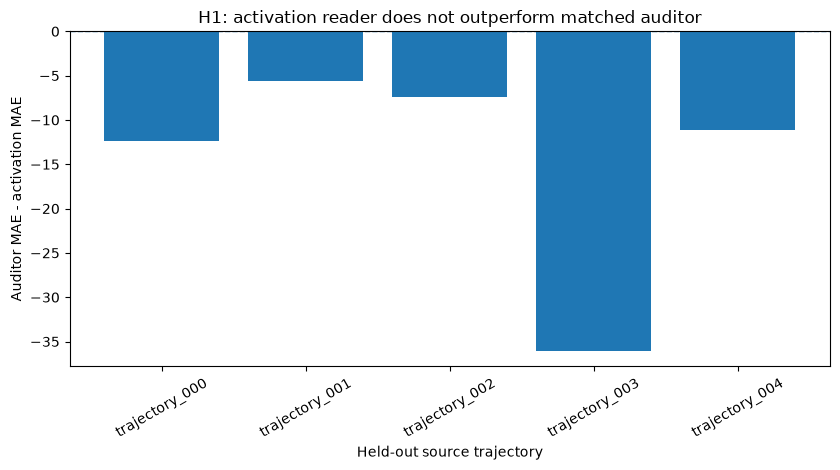

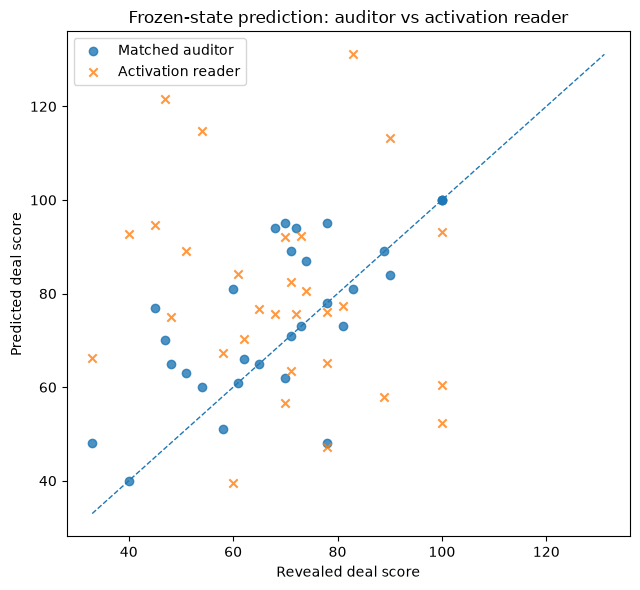

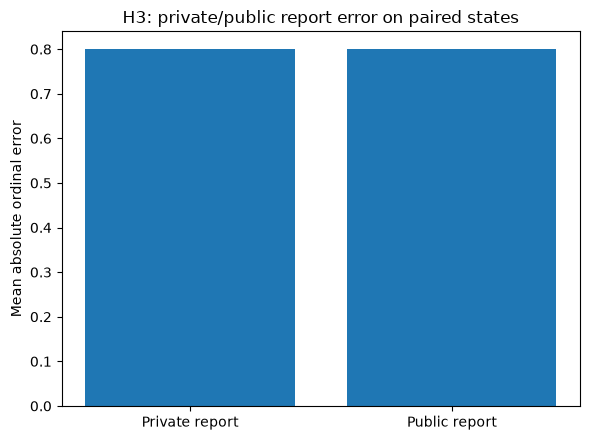

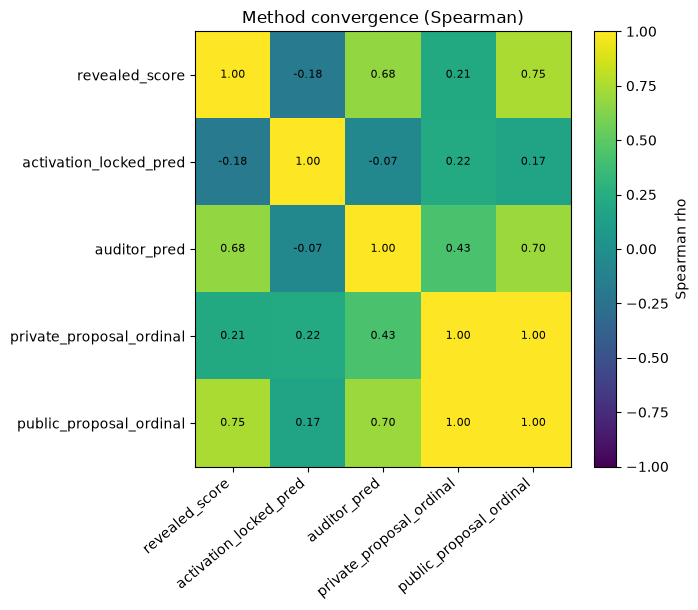

In [12]:
import matplotlib.pyplot as plt

# Figure 1: per-trajectory primary H1 effect.
fig,ax=plt.subplots(figsize=(8.5,4.8))
ax.bar(fold_df['trajectory_id'],fold_df['delta_auditor_minus_activation'])
ax.axhline(0,linestyle='--',linewidth=1)
ax.set_ylabel('Auditor MAE - activation MAE')
ax.set_xlabel('Held-out source trajectory')
ax.set_title('H1: activation reader does not outperform matched auditor')
ax.tick_params(axis='x',rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR/'figure_h1_delta_by_trajectory.png',dpi=220)
plt.show()

# Figure 2: state-level prediction comparison.
fig,ax=plt.subplots(figsize=(6.5,6.0))
ax.scatter(y,aud,label='Matched auditor',alpha=.8)
ax.scatter(y,locked_pred,label='Activation reader',alpha=.8,marker='x')
lo=float(min(y.min(),aud.min(),locked_pred.min())); hi=float(max(y.max(),aud.max(),locked_pred.max()))
ax.plot([lo,hi],[lo,hi],linestyle='--',linewidth=1)
ax.set_xlabel('Revealed deal score')
ax.set_ylabel('Predicted deal score')
ax.set_title('Frozen-state prediction: auditor vs activation reader')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR/'figure_h1_predictions.png',dpi=220)
plt.show()

# Figure 3: repaired private/public report error.
fig,ax=plt.subplots(figsize=(6.0,4.5))
ax.bar(['Private report','Public report'],[private_paired_mae,public_mae])
ax.set_ylabel('Mean absolute ordinal error')
ax.set_title('H3: private/public report error on paired states')
fig.tight_layout()
fig.savefig(FIGURE_DIR/'figure_h3_private_public_error.png',dpi=220)
plt.show()

# Figure 4: method convergence matrix.
fig,ax=plt.subplots(figsize=(7.0,6.2))
im=ax.imshow(conv.to_numpy(dtype=float),vmin=-1,vmax=1,aspect='auto')
ax.set_xticks(range(len(methods)),methods,rotation=40,ha='right')
ax.set_yticks(range(len(methods)),methods)
ax.set_title('Method convergence (Spearman)')
for i in range(len(methods)):
    for j in range(len(methods)):
        v=conv.iloc[i,j]
        if np.isfinite(v): ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='Spearman rho')
fig.tight_layout()
fig.savefig(FIGURE_DIR/'figure_method_convergence.png',dpi=220)
plt.show()


## 12. Freeze the LLM-Deliberation evidence bundle


In [13]:
summary={
 'notebook_build':NOTEBOOK_BUILD,
 'run_id':RUN_ID,
 'source_notebook02b_run':str(NB02B_RUN),
 'sample':{'states':len(idx),'trajectories':len(set(trajectory)),'public_report_pairs':len(paired)},
 'h1_primary':{
   'locked_layer':LOCKED_LAYER,
   'locked_alpha':LOCKED_ALPHA,
   'activation_loto_mae':locked_mae,
   'auditor_loto_mae':auditor_mae,
   'delta_latent_auditor_minus_activation':delta,
   'cluster_bootstrap_95ci':ci,
   'bootstrap_fraction_positive':float(np.mean(boots>0)),
   'outcome':'negative/null: activation reader does not beat the matched auditor',
 },
 'h1_secondary_nested':{
   'activation_nested_loto_mae':float(repair['nested_activation_robustness']['activation_nested_loto_mae']),
   'auditor_mae':float(repair['nested_activation_robustness']['auditor_mae']),
   'delta_auditor_minus_activation':float(repair['nested_activation_robustness']['delta_auditor_minus_activation']),
 },
 'positive_control':{
   'threshold_test_mae':float(pilot['threshold_positive_control_test_mae']),
   'threshold_layer':int(pilot['threshold_positive_control_layer']),
 },
 'h3_reports':h3,
 'controls':{
   'exact_repeat_legal_rate':float(repeat_summary['legal_rate']),
   'exact_repeat_deal_match_rate':float(repeat_summary['deal_match_rate']),
   'exact_repeat_score_match_rate':float(repeat_summary['score_match_rate']),
   'report_order_proposal_match_rate':float(order_control['proposal_match'].mean()),
   'report_order_minimum_match_rate':float(order_control['minimum_match'].mean()),
 },
 'interpretation_policy':[
   'Preserve the negative/null H1 result.',
   'Do not weaken the auditor.',
   'Do not retroactively select a new primary layer.',
   'Treat H3 as null under the tested public/private report manipulation.',
 ],
}
(TABLE_DIR/'frozen_evidence_summary.json').write_text(json.dumps(summary,indent=2))

# Compact human-readable evidence note.
note = "\n".join([
    "# Frozen LLM-Deliberation evidence",
    "",
    f"- States: {len(idx)} across {len(set(trajectory))} source trajectories.",
    f"- H1 locked activation MAE: {locked_mae:.3f}.",
    f"- H1 matched auditor MAE: {auditor_mae:.3f}.",
    f"- Delta_latent: {delta:.3f}, trajectory-cluster 95% CI [{ci[0]:.3f}, {ci[1]:.3f}].",
    f"- Secondary nested activation MAE: {repair['nested_activation_robustness']['activation_nested_loto_mae']:.3f}; delta vs auditor {repair['nested_activation_robustness']['delta_auditor_minus_activation']:.3f}.",
    f"- Assigned-threshold positive-control test MAE: {pilot['threshold_positive_control_test_mae']:.3f}.",
    f"- Exact-repeat deal and score match: {repeat_summary['deal_match_rate']:.0%} / {repeat_summary['score_match_rate']:.0%}.",
    f"- Repaired H3 public-minus-private error gap: {h3_gap:.3f}; paired substantive stance identity: {substantive_pair_identity:.0%}.",
    f"- Report-order control: proposal {order_control['proposal_match'].mean():.0%}, minimum acceptability {order_control['minimum_match'].mean():.0%}.",
    "",
])
(RESULTS_DIR/'frozen_evidence_summary.md').write_text(note)
print(note)


# Frozen LLM-Deliberation evidence

- States: 30 across 5 source trajectories.
- H1 locked activation MAE: 24.895.
- H1 matched auditor MAE: 10.400.
- Delta_latent: -14.495, trajectory-cluster 95% CI [-25.560, -7.304].
- Secondary nested activation MAE: 19.483; delta vs auditor -9.083.
- Assigned-threshold positive-control test MAE: 3.239.
- Exact-repeat deal and score match: 100% / 100%.
- Repaired H3 public-minus-private error gap: 0.000; paired substantive stance identity: 100%.
- Report-order control: proposal 80%, minimum acceptability 100%.



## 13. Hash final artifacts and close the freeze


In [14]:
output_files=sorted([p for p in RESULTS_DIR.rglob('*') if p.is_file()])
output_hashes={str(p.relative_to(RESULTS_DIR)):sha256_file(p) for p in tqdm(output_files,desc='Hash final artifacts',unit='file')}
(MANIFEST_DIR/'frozen_output_hashes.json').write_text(json.dumps(output_hashes,indent=2))
freeze_manifest={
 'notebook_build':NOTEBOOK_BUILD,
 'run_id':RUN_ID,
 'source_notebook02b_run':str(NB02B_RUN),
 'input_hash_manifest':str(MANIFEST_DIR/'frozen_input_hashes.json'),
 'output_hash_manifest':str(MANIFEST_DIR/'frozen_output_hashes.json'),
 'summary':str(TABLE_DIR/'frozen_evidence_summary.json'),
 'figures':sorted(str(p) for p in FIGURE_DIR.glob('*.png')),
 'tables':sorted(str(p) for p in TABLE_DIR.glob('*')),
 'frozen':True,
}
(MANIFEST_DIR/'notebook03_freeze_manifest.json').write_text(json.dumps(freeze_manifest,indent=2))
print('Notebook 03 complete.')
print(f"Frozen summary: {TABLE_DIR/'frozen_evidence_summary.json'}")
print(f"Freeze manifest: {MANIFEST_DIR/'notebook03_freeze_manifest.json'}")
print(f"Run directory: {RUN_OUTPUT_DIR}")


Hash final artifacts:   0%|          | 0/14 [00:00<?, ?file/s]

Notebook 03 complete.
Frozen summary: /workspace/latent-reservations/notebook_outputs/03_llm_deliberation_evidence_freeze/20260814T014816Z/results/tables/frozen_evidence_summary.json
Freeze manifest: /workspace/latent-reservations/notebook_outputs/03_llm_deliberation_evidence_freeze/20260814T014816Z/manifests/notebook03_freeze_manifest.json
Run directory: /workspace/latent-reservations/notebook_outputs/03_llm_deliberation_evidence_freeze/20260814T014816Z
